Mounted at /content/drive
Regenerating Figure 2 with canonical passive benchmark
RUN_ID: 20260723_140954
Source-aware return matrix: /content/drive/MyDrive/AURORA_TWETF/outputs/ROMA_AURORA_TWETF/source_aware_unified_paper_comparison/run_20260625_065916/returns/notebook13B_source_aware_strict_test_return_matrix.parquet
Canonical passive return matrix: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/canonical_passive_benchmarks/run_20260723_035525/returns/canonical_passive_strict_test_return_matrix.parquet
Source-aware matrix shape: (319, 45)
Canonical passive matrix shape: (319, 4)

Matched Figure 2 columns:
AURORA10-UAMV-B              <- AURORA10_UAMV_B_more60_defensive
ROMA-P4                      <- ROMA_P4_balanced_regime_blend
ROMA-B12                     <- ROMA_B12_ma_timing_equal_weight
Canonical 00881-only passive <- Canonical 00881-only

Common Figure 2 dates: 319 2024-11-27 to 2026-03-25

Saved mapping table: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/

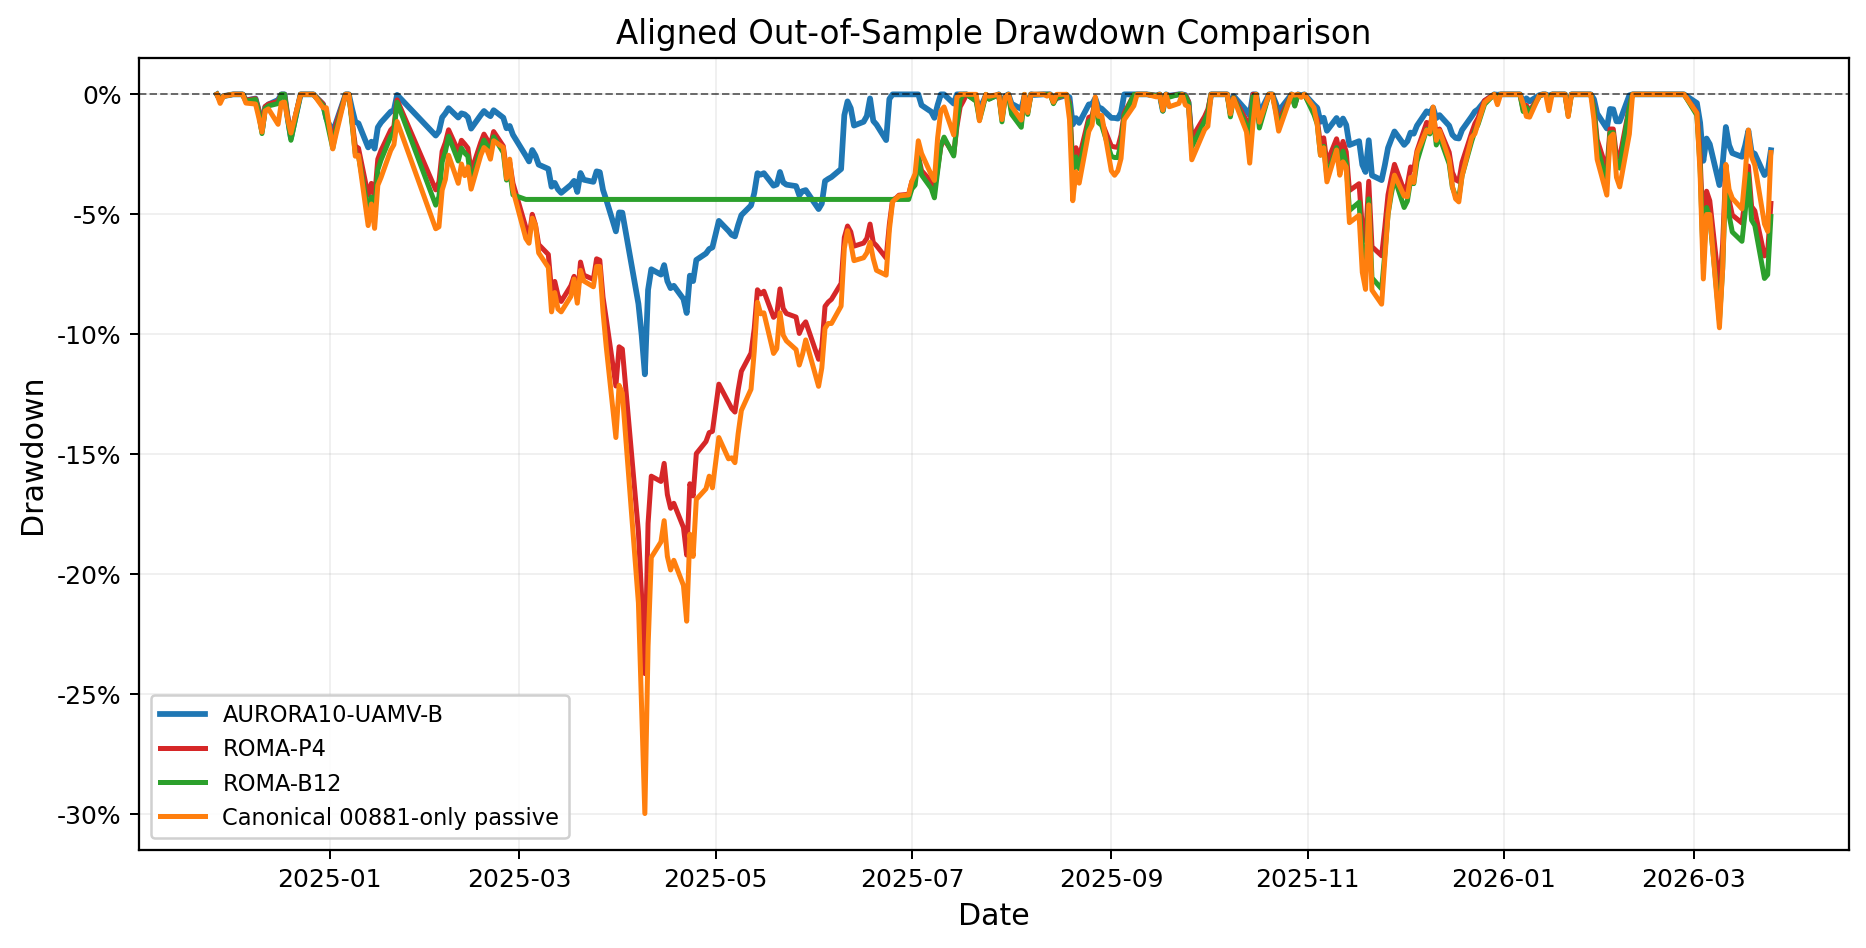


Saved PNG: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/figures/figure_2_drawdown_canonical_passive_20260723_140954.png
Saved PDF: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/figures/figure_2_drawdown_canonical_passive_20260723_140954.pdf
Saved SVG: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/figures/figure_2_drawdown_canonical_passive_20260723_140954.svg
Saved stable PNG: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/figures/figure_2_drawdown_canonical_passive.png
Saved stable PDF: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/figures/figure_2_drawdown_canonical_passive.pdf
Saved stable SVG: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/figures/figure_2_drawdown_canonical_passive.svg

Saved validation report: /content/drive/MyDrive/AURORA_TWETF/outputs/AURORA_TWETF/reports/figure2_canonical_passive_validation_report_20260723_140954.json
Saved stable validation report: /content/drive/MyDrive/AURORA_TWETF/outputs/AU

In [1]:
# ============================================================
# AURORA-TWETF Figure 2 regeneration
# Corrected drawdown figure with canonical passive benchmark
#
# Purpose:
# - Replace source-specific ROMA-B6 in Figure 2
# - Use Canonical 00881-only passive benchmark instead
#
# Plot series:
# - AURORA10-UAMV-B
# - ROMA-P4
# - ROMA-B12
# - Canonical 00881-only passive
#
# Output:
# - figure_2_drawdown_canonical_passive.png
# - figure_2_drawdown_canonical_passive.pdf
# - figure_2_drawdown_canonical_passive.svg
# - table_figure2_series_mapping_<RUN_ID>.csv
# - table_figure2_drawdown_summary_<RUN_ID>.csv
# - figure2_return_matrix_canonical_passive_<RUN_ID>.csv
# - figure2_canonical_passive_validation_report_<RUN_ID>.json
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import re
import json
import warnings

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    print("Google Drive already mounted or unavailable.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. User settings
# ============================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/AURORA_TWETF")
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "AURORA_TWETF"

STRICT_START = pd.Timestamp("2024-11-27")
STRICT_END = pd.Timestamp("2026-03-25")

RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")

FIGURE_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"

for d in [FIGURE_DIR, TABLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 100)
print("Regenerating Figure 2 with canonical passive benchmark")
print("RUN_ID:", RUN_ID)
print("=" * 100)

# ============================================================
# 1. Utility functions
# ============================================================

def normalize_name(x):
    return re.sub(r"[^A-Za-z0-9]+", "", str(x)).lower()


def read_table_auto(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
    elif path.suffix.lower() == ".csv":
        df = pd.read_csv(path, low_memory=False)
    else:
        raise ValueError(f"Unsupported file type: {path}")

    if isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        df.index.name = "date"
        return df.sort_index()

    possible_date_cols = [
        "date", "Date", "DATE", "datetime", "Datetime",
        "timestamp", "Timestamp", "Unnamed: 0", "index", "Index"
    ]

    for c in possible_date_cols:
        if c in df.columns:
            parsed = pd.to_datetime(df[c], errors="coerce")
            if parsed.notna().mean() > 0.8:
                df = df.drop(columns=[c])
                df.index = parsed
                df.index.name = "date"
                df = df[~df.index.isna()]
                return df.sort_index()

    first_col = df.columns[0]
    parsed = pd.to_datetime(df[first_col], errors="coerce")
    if parsed.notna().mean() > 0.8:
        df = df.drop(columns=[first_col])
        df.index = parsed
        df.index.name = "date"
        df = df[~df.index.isna()]
        return df.sort_index()

    raise ValueError(f"Could not identify date column in {path}")


def find_latest_file(root, patterns):
    root = Path(root)
    if isinstance(patterns, str):
        patterns = [patterns]

    candidates = []
    for pat in patterns:
        candidates.extend(root.rglob(pat))

    candidates = [p for p in candidates if p.is_file()]
    if not candidates:
        return None

    return sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True)[0]


def extract_column_strict(df, exact_candidates, label):
    """
    Exact and normalized-exact matching only.
    This avoids accidental passive/timing confusion.
    """
    cols = list(df.columns)
    norm_map = {normalize_name(c): c for c in cols}

    for cand in exact_candidates:
        if cand in cols:
            s = pd.to_numeric(df[cand], errors="coerce")
            s.name = label
            return s.dropna(), cand

    for cand in exact_candidates:
        nc = normalize_name(cand)
        if nc in norm_map:
            col = norm_map[nc]
            s = pd.to_numeric(df[col], errors="coerce")
            s.name = label
            return s.dropna(), col

    available = "\n".join(cols[:120])
    raise KeyError(
        f"Could not find column for {label}.\n"
        f"Tried: {exact_candidates}\n\n"
        f"Available columns include:\n{available}"
    )


def drawdown_from_returns(r):
    r = pd.Series(r).dropna().astype(float)
    wealth = (1.0 + r).cumprod()
    dd = wealth / wealth.cummax() - 1.0
    return dd


def performance_summary(r):
    r = pd.Series(r).dropna().astype(float)
    wealth = (1.0 + r).cumprod()
    dd = wealth / wealth.cummax() - 1.0

    return {
        "n_days": int(len(r)),
        "start_date": str(r.index.min().date()),
        "end_date": str(r.index.max().date()),
        "total_return": float(wealth.iloc[-1] - 1.0),
        "max_drawdown": float(dd.min()),
        "drawdown_end_date": str(dd.idxmin().date()),
    }


# ============================================================
# 2. Locate input files
# ============================================================

source_aware_path = find_latest_file(
    PROJECT_ROOT / "outputs",
    [
        "notebook13B_source_aware_strict_test_return_matrix.parquet",
        "notebook13B_source_aware_strict_test_return_matrix.csv",
        "*source_aware*strict*return*matrix*.parquet",
        "*source_aware*strict*return*matrix*.csv",
    ],
)

canonical_path = find_latest_file(
    OUTPUT_ROOT / "canonical_passive_benchmarks",
    [
        "canonical_passive_strict_test_return_matrix.parquet",
        "canonical_passive_strict_test_return_matrix.csv",
    ],
)

if source_aware_path is None:
    raise FileNotFoundError(
        "Could not find source-aware strict-test return matrix under PROJECT_ROOT / outputs."
    )

if canonical_path is None:
    raise FileNotFoundError(
        "Could not find canonical passive return matrix. Please run Notebook 23 first."
    )

print("Source-aware return matrix:", source_aware_path)
print("Canonical passive return matrix:", canonical_path)

source_df = read_table_auto(source_aware_path)
canonical_df = read_table_auto(canonical_path)

source_df = source_df.loc[(source_df.index >= STRICT_START) & (source_df.index <= STRICT_END)].copy()
canonical_df = canonical_df.loc[(canonical_df.index >= STRICT_START) & (canonical_df.index <= STRICT_END)].copy()

print("Source-aware matrix shape:", source_df.shape)
print("Canonical passive matrix shape:", canonical_df.shape)

# ============================================================
# 3. Extract required return series
# Corrected for actual source-aware matrix column names
# ============================================================

aurora_ret, aurora_col = extract_column_strict(
    source_df,
    [
        "AURORA10_UAMV_B_more60_defensive",
        "AURORA10-UAMV-B",
        "AURORA10_UAMV_B",
        "AURORA10_UAMV_B_return",
        "AURORA10_UAMV_B_net_return",
    ],
    "AURORA10-UAMV-B",
)

roma_p4_ret, roma_p4_col = extract_column_strict(
    source_df,
    [
        "ROMA_P4_balanced_regime_blend",
        "ROMA-P4",
        "ROMA_P4",
        "ROMA_P4_return",
        "ROMA_P4_net_return",
    ],
    "ROMA-P4",
)

roma_b12_ret, roma_b12_col = extract_column_strict(
    source_df,
    [
        "ROMA_B12_ma_timing_equal_weight",
        "ROMA-B12",
        "ROMA_B12",
        "ROMA_B12_ma_timing",
    ],
    "ROMA-B12",
)

canonical_00881_ret, canonical_00881_col = extract_column_strict(
    canonical_df,
    [
        "Canonical 00881-only",
        "Canonical_00881_only",
        "Canonical 00881-only passive",
    ],
    "Canonical 00881-only passive",
)

series = {
    "AURORA10-UAMV-B": aurora_ret,
    "ROMA-P4": roma_p4_ret,
    "ROMA-B12": roma_b12_ret,
    "Canonical 00881-only passive": canonical_00881_ret,
}

print("\nMatched Figure 2 columns:")
print(f"AURORA10-UAMV-B              <- {aurora_col}")
print(f"ROMA-P4                      <- {roma_p4_col}")
print(f"ROMA-B12                     <- {roma_b12_col}")
print(f"Canonical 00881-only passive <- {canonical_00881_col}")

# ============================================================
# 4. Common-date alignment
# ============================================================

common_dates = None
for s in series.values():
    idx = pd.DatetimeIndex(s.index)
    if common_dates is None:
        common_dates = idx
    else:
        common_dates = common_dates.intersection(idx)

common_dates = common_dates.sort_values()
common_dates = common_dates[(common_dates >= STRICT_START) & (common_dates <= STRICT_END)]

if len(common_dates) == 0:
    raise ValueError("No common dates across Figure 2 return series.")

ret_mat = pd.DataFrame({name: s.reindex(common_dates) for name, s in series.items()})
ret_mat = ret_mat.dropna(how="any")

if len(ret_mat) == 0:
    raise ValueError("Return matrix has zero rows after dropping missing values.")

print("\nCommon Figure 2 dates:", len(ret_mat), ret_mat.index.min().date(), "to", ret_mat.index.max().date())

# ============================================================
# 5. Save mapping and return matrix
# ============================================================

mapping_df = pd.DataFrame(
    [
        {
            "plot_label": "AURORA10-UAMV-B",
            "source_file": str(source_aware_path),
            "source_column": aurora_col,
            "role": "Primary defensive AURORA variant",
        },
        {
            "plot_label": "ROMA-P4",
            "source_file": str(source_aware_path),
            "source_column": roma_p4_col,
            "role": "Primary ROMA baseline",
        },
        {
            "plot_label": "ROMA-B12",
            "source_file": str(source_aware_path),
            "source_column": roma_b12_col,
            "role": "ETF-level 126-day MA timing benchmark",
        },
        {
            "plot_label": "Canonical 00881-only passive",
            "source_file": str(canonical_path),
            "source_column": canonical_00881_col,
            "role": "Canonical technology-oriented passive benchmark",
        },
    ]
)

mapping_path = TABLE_DIR / f"table_figure2_series_mapping_{RUN_ID}.csv"
stable_mapping_path = TABLE_DIR / "table_figure2_series_mapping.csv"
mapping_df.to_csv(mapping_path, index=False)
mapping_df.to_csv(stable_mapping_path, index=False)

ret_mat_path = TABLE_DIR / f"figure2_return_matrix_canonical_passive_{RUN_ID}.csv"
stable_ret_mat_path = TABLE_DIR / "figure2_return_matrix_canonical_passive.csv"
ret_mat.to_csv(ret_mat_path)
ret_mat.to_csv(stable_ret_mat_path)

print("\nSaved mapping table:", mapping_path)
print("Saved stable mapping table:", stable_mapping_path)
print("Saved Figure 2 return matrix:", ret_mat_path)
print("Saved stable Figure 2 return matrix:", stable_ret_mat_path)

# ============================================================
# 6. Generate drawdown series and summary table
# ============================================================

dd_mat = pd.DataFrame({name: drawdown_from_returns(ret_mat[name]) for name in ret_mat.columns})

summary_df = pd.DataFrame(
    [{"strategy": name, **performance_summary(ret_mat[name])} for name in ret_mat.columns]
)

summary_path = TABLE_DIR / f"table_figure2_drawdown_summary_{RUN_ID}.csv"
stable_summary_path = TABLE_DIR / "table_figure2_drawdown_summary.csv"
summary_df.to_csv(summary_path, index=False)
summary_df.to_csv(stable_summary_path, index=False)

print("\nSaved summary table:", summary_path)
print("Saved stable summary table:", stable_summary_path)
print("\nFigure 2 drawdown summary:")
print(summary_df.round(6).to_string(index=False))

# ============================================================
# 7. Plot corrected Figure 2
# ============================================================

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

fig, ax = plt.subplots(figsize=(10.5, 5.4), dpi=180)

plot_styles = {
    "AURORA10-UAMV-B": {
        "color": "#1f77b4",
        "linewidth": 2.3,
        "linestyle": "-",
    },
    "ROMA-P4": {
        "color": "#d62728",
        "linewidth": 2.0,
        "linestyle": "-",
    },
    "ROMA-B12": {
        "color": "#2ca02c",
        "linewidth": 2.0,
        "linestyle": "-",
    },
    "Canonical 00881-only passive": {
        "color": "#ff7f0e",
        "linewidth": 2.0,
        "linestyle": "-",
    },
}

for name in [
    "AURORA10-UAMV-B",
    "ROMA-P4",
    "ROMA-B12",
    "Canonical 00881-only passive",
]:
    ax.plot(
        dd_mat.index,
        dd_mat[name],
        label=name,
        **plot_styles[name],
    )

ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.55)

ax.set_title("Aligned Out-of-Sample Drawdown Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.25, linewidth=0.6)
ax.legend(loc="lower left", frameon=True, framealpha=0.92)

ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

fig.tight_layout()

png_path = FIGURE_DIR / f"figure_2_drawdown_canonical_passive_{RUN_ID}.png"
pdf_path = FIGURE_DIR / f"figure_2_drawdown_canonical_passive_{RUN_ID}.pdf"
svg_path = FIGURE_DIR / f"figure_2_drawdown_canonical_passive_{RUN_ID}.svg"

stable_png = FIGURE_DIR / "figure_2_drawdown_canonical_passive.png"
stable_pdf = FIGURE_DIR / "figure_2_drawdown_canonical_passive.pdf"
stable_svg = FIGURE_DIR / "figure_2_drawdown_canonical_passive.svg"

fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(svg_path, bbox_inches="tight")

fig.savefig(stable_png, bbox_inches="tight")
fig.savefig(stable_pdf, bbox_inches="tight")
fig.savefig(stable_svg, bbox_inches="tight")

plt.show()

print("\nSaved PNG:", png_path)
print("Saved PDF:", pdf_path)
print("Saved SVG:", svg_path)
print("Saved stable PNG:", stable_png)
print("Saved stable PDF:", stable_pdf)
print("Saved stable SVG:", stable_svg)

# ============================================================
# 8. Validation report
# ============================================================

validation_report = {
    "run_id": RUN_ID,
    "purpose": "Regenerate Figure 2 using canonical 00881-only passive benchmark instead of source-specific ROMA-B6.",
    "strict_start": str(STRICT_START.date()),
    "strict_end": str(STRICT_END.date()),
    "n_common_dates": int(len(ret_mat)),
    "common_start": str(ret_mat.index.min().date()),
    "common_end": str(ret_mat.index.max().date()),
    "source_aware_return_matrix": str(source_aware_path),
    "canonical_passive_return_matrix": str(canonical_path),
    "series_mapping": mapping_df.to_dict(orient="records"),
    "drawdown_summary": summary_df.to_dict(orient="records"),
    "outputs": {
        "png": str(stable_png),
        "pdf": str(stable_pdf),
        "svg": str(stable_svg),
        "mapping_table": str(stable_mapping_path),
        "drawdown_summary": str(stable_summary_path),
        "return_matrix": str(stable_ret_mat_path),
    },
    "caption": (
        "Figure 2. Drawdown comparison of AURORA10-UAMV-B, ROMA-P4, ROMA-B12, "
        "and the canonical 00881-only passive benchmark during the aligned out-of-sample evaluation window."
    ),
}

report_path = REPORT_DIR / f"figure2_canonical_passive_validation_report_{RUN_ID}.json"
report_stable_path = REPORT_DIR / "figure2_canonical_passive_validation_report.json"

report_path.write_text(json.dumps(validation_report, indent=2, ensure_ascii=False), encoding="utf-8")
report_stable_path.write_text(json.dumps(validation_report, indent=2, ensure_ascii=False), encoding="utf-8")

print("\nSaved validation report:", report_path)
print("Saved stable validation report:", report_stable_path)

print("=" * 100)
print("Figure 2 regeneration complete.")
print("=" * 100)

print("\nUse this manuscript caption:")
print(
    "Figure 2. Drawdown comparison of AURORA10-UAMV-B, ROMA-P4, ROMA-B12, "
    "and the canonical 00881-only passive benchmark during the aligned out-of-sample evaluation window."
)

print("\nUse this Section 4.2 sentence:")
print(
    "During the early-2025 drawdown episode, AURORA10-UAMV-B experiences a less severe drawdown "
    "than ROMA-P4 and the canonical 00881-only passive benchmark. However, ROMA-B12 has the least "
    "severe maximum drawdown among the plotted strategies."
)